# Transforms

`epilearn.utils.transforms` holds the preprocessing blocks. A `Compose` groups them by the part of
the dataset they act on (`features`, `target`, `graph`, `dynamic_graph`, `states`).

Two things changed in 0.1.0 and they are easy to miss because neither raises:

1. **`Compose.__call__` returns a tuple** `(data, process_history)`. `data = transformation(data)`
   now silently binds a tuple.
2. **`Compose.feat_mean` / `.feat_std` are gone.** The normalisation statistics live in
   `Compose.process_history` (and, once a `Dataset` has applied them,
   `dataset.get_process_history()`), keyed `feat_mean`, `feat_std`, `target_mean`, `target_std`.

`Dataset.get_transformed()` was also removed; use `set_transforms()` / `apply_transforms()`.

In [1]:
import os
import sys

# Run from the repository root so that "./datasets" (and "./examples") resolve,
# no matter whether this notebook was launched from examples/ or from the root.
if os.path.basename(os.getcwd()) == "examples":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

In [2]:
import torch
import matplotlib.pyplot as plt

from epilearn.data import Dataset
from epilearn.utils import transforms
from epilearn.models.SpatialTemporal import STGCN
from epilearn.tasks.forecast import Forecast

torch.manual_seed(7)
device = 'cpu'

/home/ec2-user/miniconda3/envs/epilearn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. `Compose` returns `(data, process_history)`

In [3]:
dataset = Dataset()
dataset.load_toy_dataset()

transformation = transforms.Compose({
                                    'features': [transforms.normalize_feat()],
                                    'target': [transforms.normalize_target()],
                                    'graph': [transforms.normalize_adj()],
                                    })

# Compose takes a dict keyed the same way and returns TWO values.
data, process_history = transformation({'features': dataset.x.clone(),
                                       'target': dataset.y.clone(),
                                       'graph': dataset.graph.clone()})

print("features:", tuple(data['features'].shape))
print("target  :", tuple(data['target'].shape))
print("graph   :", tuple(data['graph'].shape))
print("process_history:", {k: round(float(v), 4) for k, v in process_history.items()})

features: (539, 47, 4)
target  : (539, 47)
graph   : (47, 47)
process_history: {'feat_mean': 17.3214, 'feat_std': 126.8261, 'target_mean': 66.2618, 'target_std': 247.2598}


## 2. Letting the `Dataset` own the transforms

`set_transforms(t)` stores the transform so a task applies it per rolling fold (statistics are fitted
on the training window only). `set_transforms(t, apply_now=True)` applies it immediately and rewrites
`dataset.x` / `.y` / `.graph` in place.

In [4]:
dataset = Dataset()
dataset.load_toy_dataset()
raw_y = dataset.y.clone()

dataset.set_transforms(transforms.Compose({
                                    'features': [transforms.normalize_feat()],
                                    'target': [transforms.normalize_target()],
                                    'graph': [transforms.normalize_adj()],
                                    }), apply_now=True)

history = dataset.get_process_history()
print("stats:", {k: round(float(v), 4) for k, v in history.items()})
print("normalized target  mean/std:", round(float(dataset.y.mean()), 4), round(float(dataset.y.std()), 4))

# undo it: preds * target_std + target_mean
restored = dataset.y * history['target_std'] + history['target_mean']
print("max |restored - raw|:", float((restored - raw_y).abs().max()))

stats: {'feat_mean': 17.3214, 'feat_std': 126.8261, 'target_mean': 66.2618, 'target_std': 247.2598}
normalized target  mean/std: -0.0 1.0
max |restored - raw|: 0.0001220703125


## 3. The windowed transforms

`add_time_embedding`, `learnable_time_embedding` and `convert_to_frequency` read the input as
`(samples, nodes, time, channels)` -- i.e. they belong on the *windowed* tensor produced by
`generate_dataset(..., permute=True)`, not on the raw `(time, nodes, channels)` array. They take the
target device as a keyword.

In [5]:
windowed = dataset.generate_dataset(X=dataset.x, Y=dataset.y, adj=dataset.graph,
                                    lookback_window_size=12, horizon_size=3,
                                    permute=True)['features'][:8]
print("windowed (samples, nodes, time, channels):", tuple(windowed.shape))

for name, t in [
    ('add_time_embedding(4)', transforms.add_time_embedding(embedding_dim=4)),
    ('add_time_embedding(4, fourier=True)', transforms.add_time_embedding(embedding_dim=4, fourier=True)),
    ('learnable_time_embedding(12, 4)', transforms.learnable_time_embedding(timesteps=12, embedding_dim=4)),
    ('convert_to_frequency("fft")', transforms.convert_to_frequency(ftype='fft')),
]:
    out = t(windowed.clone(), device=device)
    print(f"{name:38s} -> {tuple(out.shape)}")

windowed (samples, nodes, time, channels): (8, 47, 12, 4)
add_time_embedding(4)                  -> (8, 47, 12, 8)
add_time_embedding(4, fourier=True)    -> (8, 47, 12, 8)
learnable_time_embedding(12, 4)        -> (8, 47, 12, 8)
convert_to_frequency("fft")            -> (8, 47, 12, 4)


`seasonality_and_trend_decompose` is the odd one out: it wants `(samples, nodes, time)` and returns
a **list** `[seasonality, trend]`, so it cannot be chained inside a `Compose`.

input: (8, 47, 12) -> seasonality/trend: (8, 12, 47)


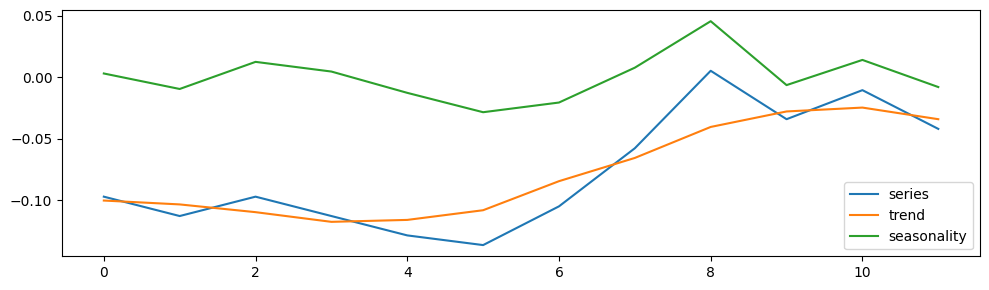

In [6]:
series = windowed[..., 0]           # (samples, nodes, time)
seasonality, trend = transforms.seasonality_and_trend_decompose(
    decompose_type='static', moving_avg=5)(series.clone(), device=device)
print("input:", tuple(series.shape), "-> seasonality/trend:", tuple(seasonality.shape))

plt.figure(figsize=(10, 3))
plt.plot(series[0, 0].numpy(), label='series')
plt.plot(trend[0, :, 0].numpy(), label='trend')
plt.plot(seasonality[0, :, 0].numpy(), label='seasonality')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Transforms inside a task

Hand the `Compose` to the dataset and let `rolling_train` apply it fold by fold. Because
`normalize_target()` is in the pipeline, the reported MSE/MAE/RMSE and the conformal interval widths
are in **normalized** units -- pass `inverse_normalize=True` (plus the fold's `process_history`) to
`evaluate_model` to get case counts back.

In [7]:
dataset = Dataset()
dataset.load_toy_dataset()
dataset.set_transforms(transforms.Compose({
                                    'features': [transforms.normalize_feat()],
                                    'target': [transforms.normalize_target()],
                                    'graph': [transforms.normalize_adj()],
                                    }))

task = Forecast(prototype=STGCN, dataset=None, lookback=12, horizon=3, device=device)
result = task.rolling_train(dataset=dataset,
                            train_size=300, val_size=60, test_size=60,
                            train_loss='mse', epochs=10, batch_size=16,
                            max_folds=2)

print("\nnormalized MAE:", round(result['aggregate_metrics']['mae_mean'], 4))


Rolling Evaluation Setup


Train: 300, Val: 60, Test: 60, Step: 60



--- Fold 1 ---


Train: 300 [0 - 299]


Val:   60 [300 - 359]


...

  Quantile: 0.8217 ± 0.4084


  Coverage: 83.1% ± 14.0%


  Interval Width: 1.6433 ± 0.8167



Total time: 11.51s, Memory: +284.26 MB



normalized MAE: 0.3625



MODEL EVALUATION

--- Point Metrics ---
MSE:              3232.001953
MAE:              20.963348
RMSE:             56.850700
MAPE:             13637134336.00%
R²:               0.809476
Median AE:        10.836487
Max Error:        1183.156738

--- Residual Statistics ---
Mean:             2.060683
Std Dev:          56.817719

MAE in cases: 20.963
Data shape: (46, 47, 3) (time, regions, horizon)
Plotting region 0, horizon step -1
Plotting 40 time samples


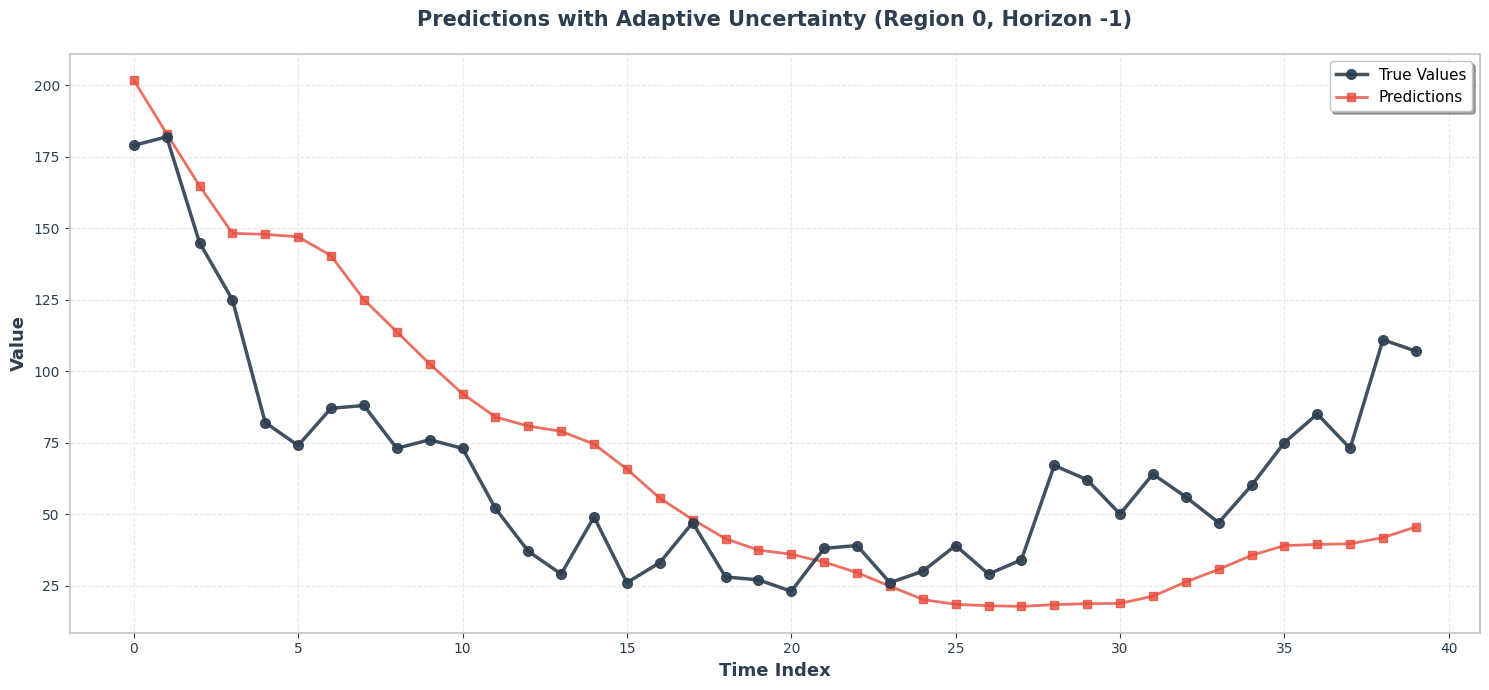

In [8]:
fold = result['fold_results'][-1]

evaluation = task.evaluate_model(dataset=fold['test_split'],
                                 process_history=fold['process_history'],
                                 inverse_normalize=True)
print("\nMAE in cases:", round(float(evaluation['mae']), 3))

fig, ax = task.plot_preds(evaluation, n_show=40, region_idx=0, horizon_idx=-1)
plt.show()